# Resource Estimation of Hamiltonian Simulation of the SYK Model

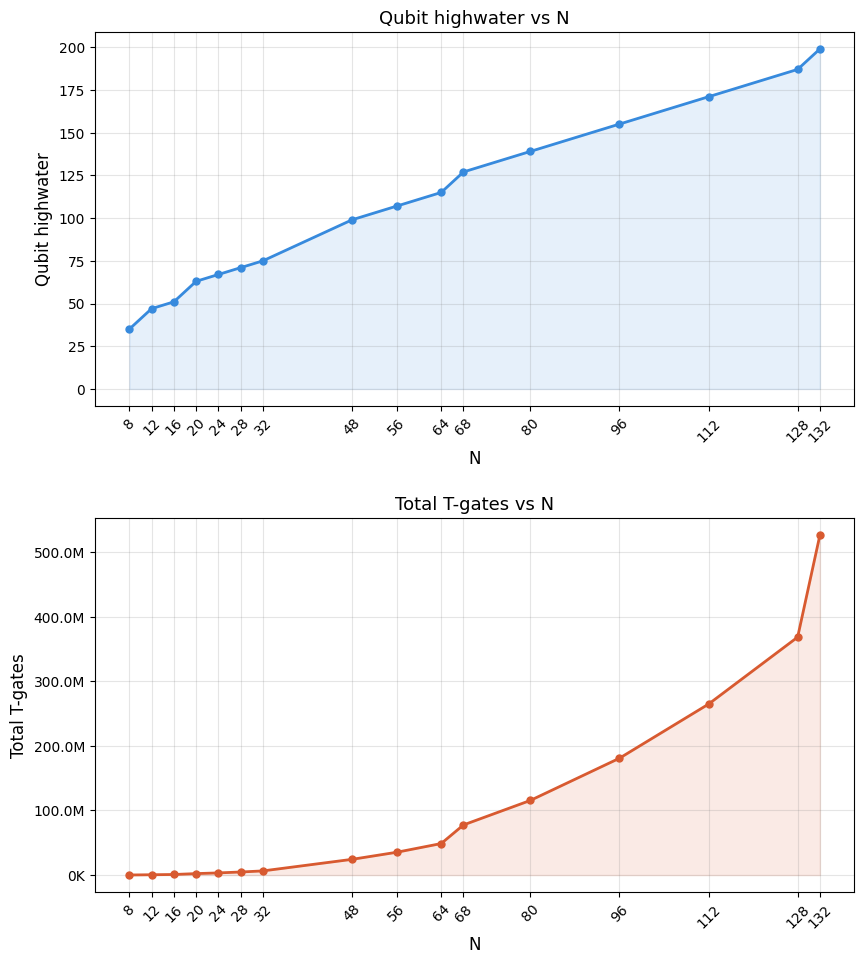

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("re_data/scale_N_J1_order1.csv")

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# --- Qubit highwater ---
axes[0].plot(df["N"], df["qubit_highwater"], color="#378ADD", marker="o",
             linewidth=2, markersize=5)
axes[0].fill_between(df["N"], df["qubit_highwater"], alpha=0.12, color="#378ADD")
axes[0].set_xlabel("N", fontsize=12)
axes[0].set_ylabel("Qubit highwater", fontsize=12)
axes[0].set_title("Qubit highwater vs N", fontsize=13)
axes[0].set_xticks(df["N"])
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, color="gray", alpha=0.2)

# --- Total T-gates ---
axes[1].plot(df["N"], df["total_t_gates"], color="#D85A30", marker="o",
             linewidth=2, markersize=5)
axes[1].fill_between(df["N"], df["total_t_gates"], alpha=0.12, color="#D85A30")
axes[1].set_xlabel("N", fontsize=12)
axes[1].set_ylabel("Total T-gates", fontsize=12)
axes[1].set_title("Total T-gates vs N", fontsize=13)
axes[1].set_xticks(df["N"])
axes[1].tick_params(axis="x", rotation=45)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
axes[1].grid(True, color="gray", alpha=0.2)

plt.tight_layout(pad=2.0)
plt.show()

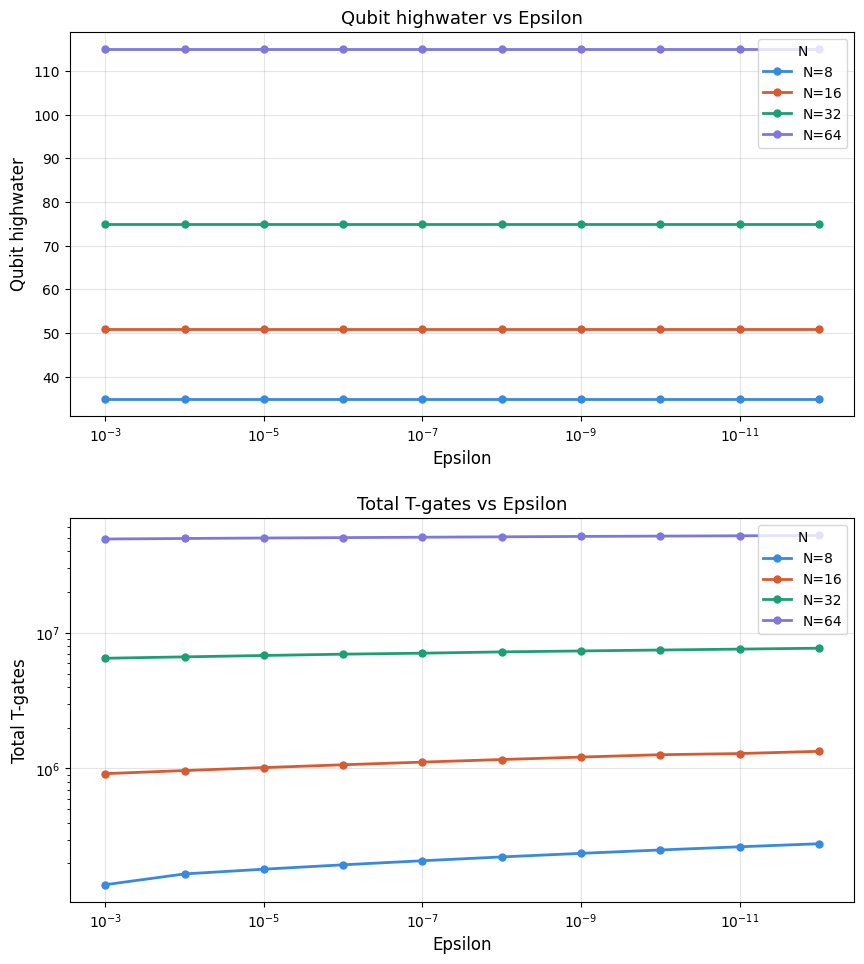

In [19]:
df = pd.read_csv("re_data/scale_eps_J1_order1.csv")

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

colors = {8: "#378ADD", 16: "#D85A30", 32: "#1D9E75", 64: "#7F77DD"}

for N, group in df.groupby("N"):
    group = group.sort_values("epsilon")
    color = colors[N]

    axes[0].plot(group["epsilon"], group["qubit_highwater"], color=color,
                 marker="o", linewidth=2, markersize=5, label=f"N={N}")

    axes[1].plot(group["epsilon"], group["total_t_gates"], color=color,
                 marker="o", linewidth=2, markersize=5, label=f"N={N}")

# --- Qubit highwater ---
axes[0].set_xscale("log")
axes[0].invert_xaxis()
axes[0].set_xlabel("Epsilon", fontsize=12)
axes[0].set_ylabel("Qubit highwater", fontsize=12)
axes[0].set_title("Qubit highwater vs Epsilon", fontsize=13)
axes[0].legend(title="N")
axes[0].grid(True, color="gray", alpha=0.2)

# --- Total T-gates ---
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].invert_xaxis()
axes[1].set_xlabel("Epsilon", fontsize=12)
axes[1].set_ylabel("Total T-gates", fontsize=12)
axes[1].set_title("Total T-gates vs Epsilon", fontsize=13)
axes[1].legend(title="N")
axes[1].grid(True, color="gray", alpha=0.2)

plt.tight_layout(pad=2.0)
plt.show()